#  Machine Problem 3: Descriptive Statistics and Data Visualization

**Name:** Adeline Marie Obordo  
**Program:** Master's in Business Analytics  
**Student No:** 2025290165  

---

**Problem Set Instruction:**  
Download a dataset from Kaggle.  
Do descriptive statistics.  
Create at least 2 additional plots using seaborne.

Decriptive Statistics

In [ ]:
# %pip install pandas numpy scipy seaborn matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Heart Data.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import os

#df = pd.read_excel("change this with the file path in your Google Drive where you saved Concrete_Data.xlsx")

file_path = '/content/drive/MyDrive/Heart Data.xlsx'

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found. Please ensure the file is in your Google Drive and the path is correct.")
    # Optionally, you can stop execution here or ask for a new path
else:
    df = pd.read_excel(file_path)


# Select numeric columns only
numeric_df = df.select_dtypes(include=['number'])

#Step 1: Compute Quantitative Stat Metrics for Numeric Data and Saved Results in Excel

if numeric_df.empty:
    print("No numeric columns found in the Excel file.")

else:
    # Compute descriptive statistics
    mean = numeric_df.mean()
    median = numeric_df.median()
    variance= numeric_df.var()
    std_dev = numeric_df.std()
    minimum = numeric_df.min()
    maximum = numeric_df.max()
    count = numeric_df.count()
    mode = numeric_df.mode().iloc[0]
    kurt = numeric_df.apply(kurtosis)
    skewness = numeric_df.apply(skew)
    q = numeric_df.quantile([0.25, 0.5, 0.75])
    IQR=q.loc[0.75]-q.loc[0.25]
    Sum=numeric_df.sum()
    # Combine into a single DataFrame
    stats_df = pd.DataFrame({
            "Count": count,
            "Minimum": minimum,
            "Maximum": maximum,
            "Mean": mean,
            "Median": median,
            "Mode": mode,
            "Variance": variance,
            "Standard Deviation": std_dev,
            "25th Percentile": q.loc[0.25],
            "50th Percentile": q.loc[0.50],
            "75th Percentile": q.loc[0.75],
            "Kurtosis": kurt,
            "Skewness": skewness,
            "IQR": IQR,
            "Sum": Sum
            })

In [ ]:
# Transpose for readability
stats_df = stats_df.transpose()

In [ ]:
# Save the output to a new Excel file
stats_df.to_excel('/content/drive/MyDrive/statistical_summary.xlsx')

## Pearson correlation coefficient (r):
- Measures the linear relationship between two variables.

- Range: -1 to +1

- r = +1: perfect positive linear relationship (y is increasing with x linearly)

- r = 0: no linear relationship

- r = -1: perfect negative linear relationship (if x is increasing, y is decreasing
linearly)

## How to Read the Heatmap

- Rows and Columns: Each row and column represents a variable.

- Color Intensity: The cell color encodes the strength and direction of correlation:

- Dark Red / Deep Blue (depending on color scheme): Very strong correlation (positive or negative).

- Pale / Near White: Weak or no correlation.

- Diagonal Cells: Always show 1.0 (a variable is perfectly correlated with itself).

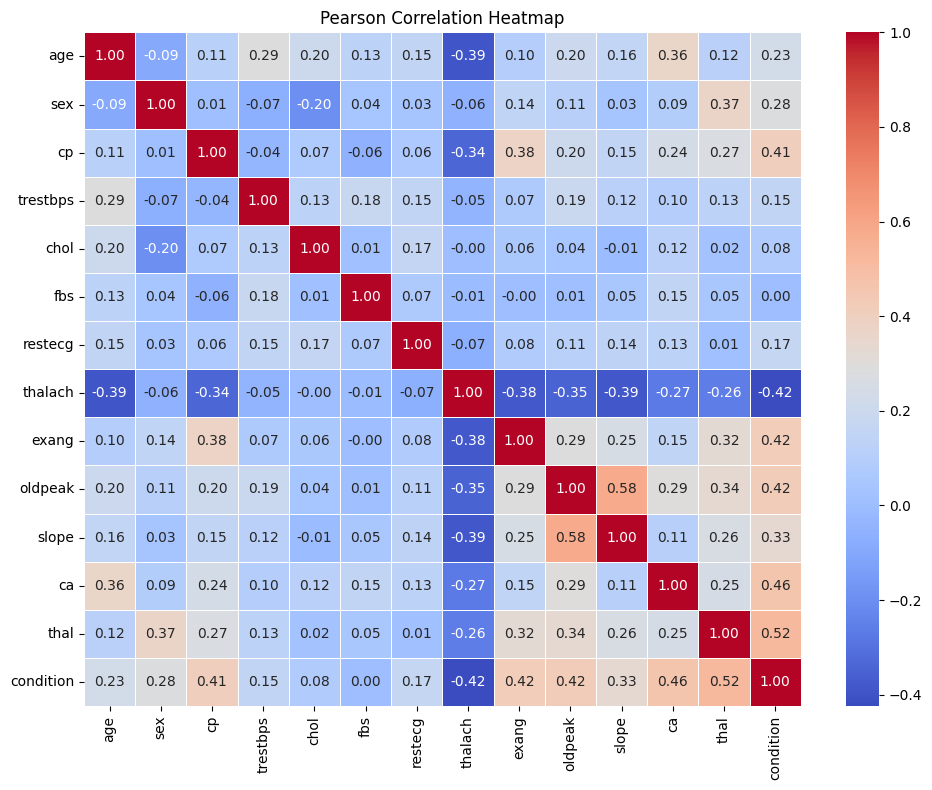

In [ ]:
# Step 2: Compute Pearson correlation

correlation_matrix = numeric_df.corr(method='pearson')

# Step 3: Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()


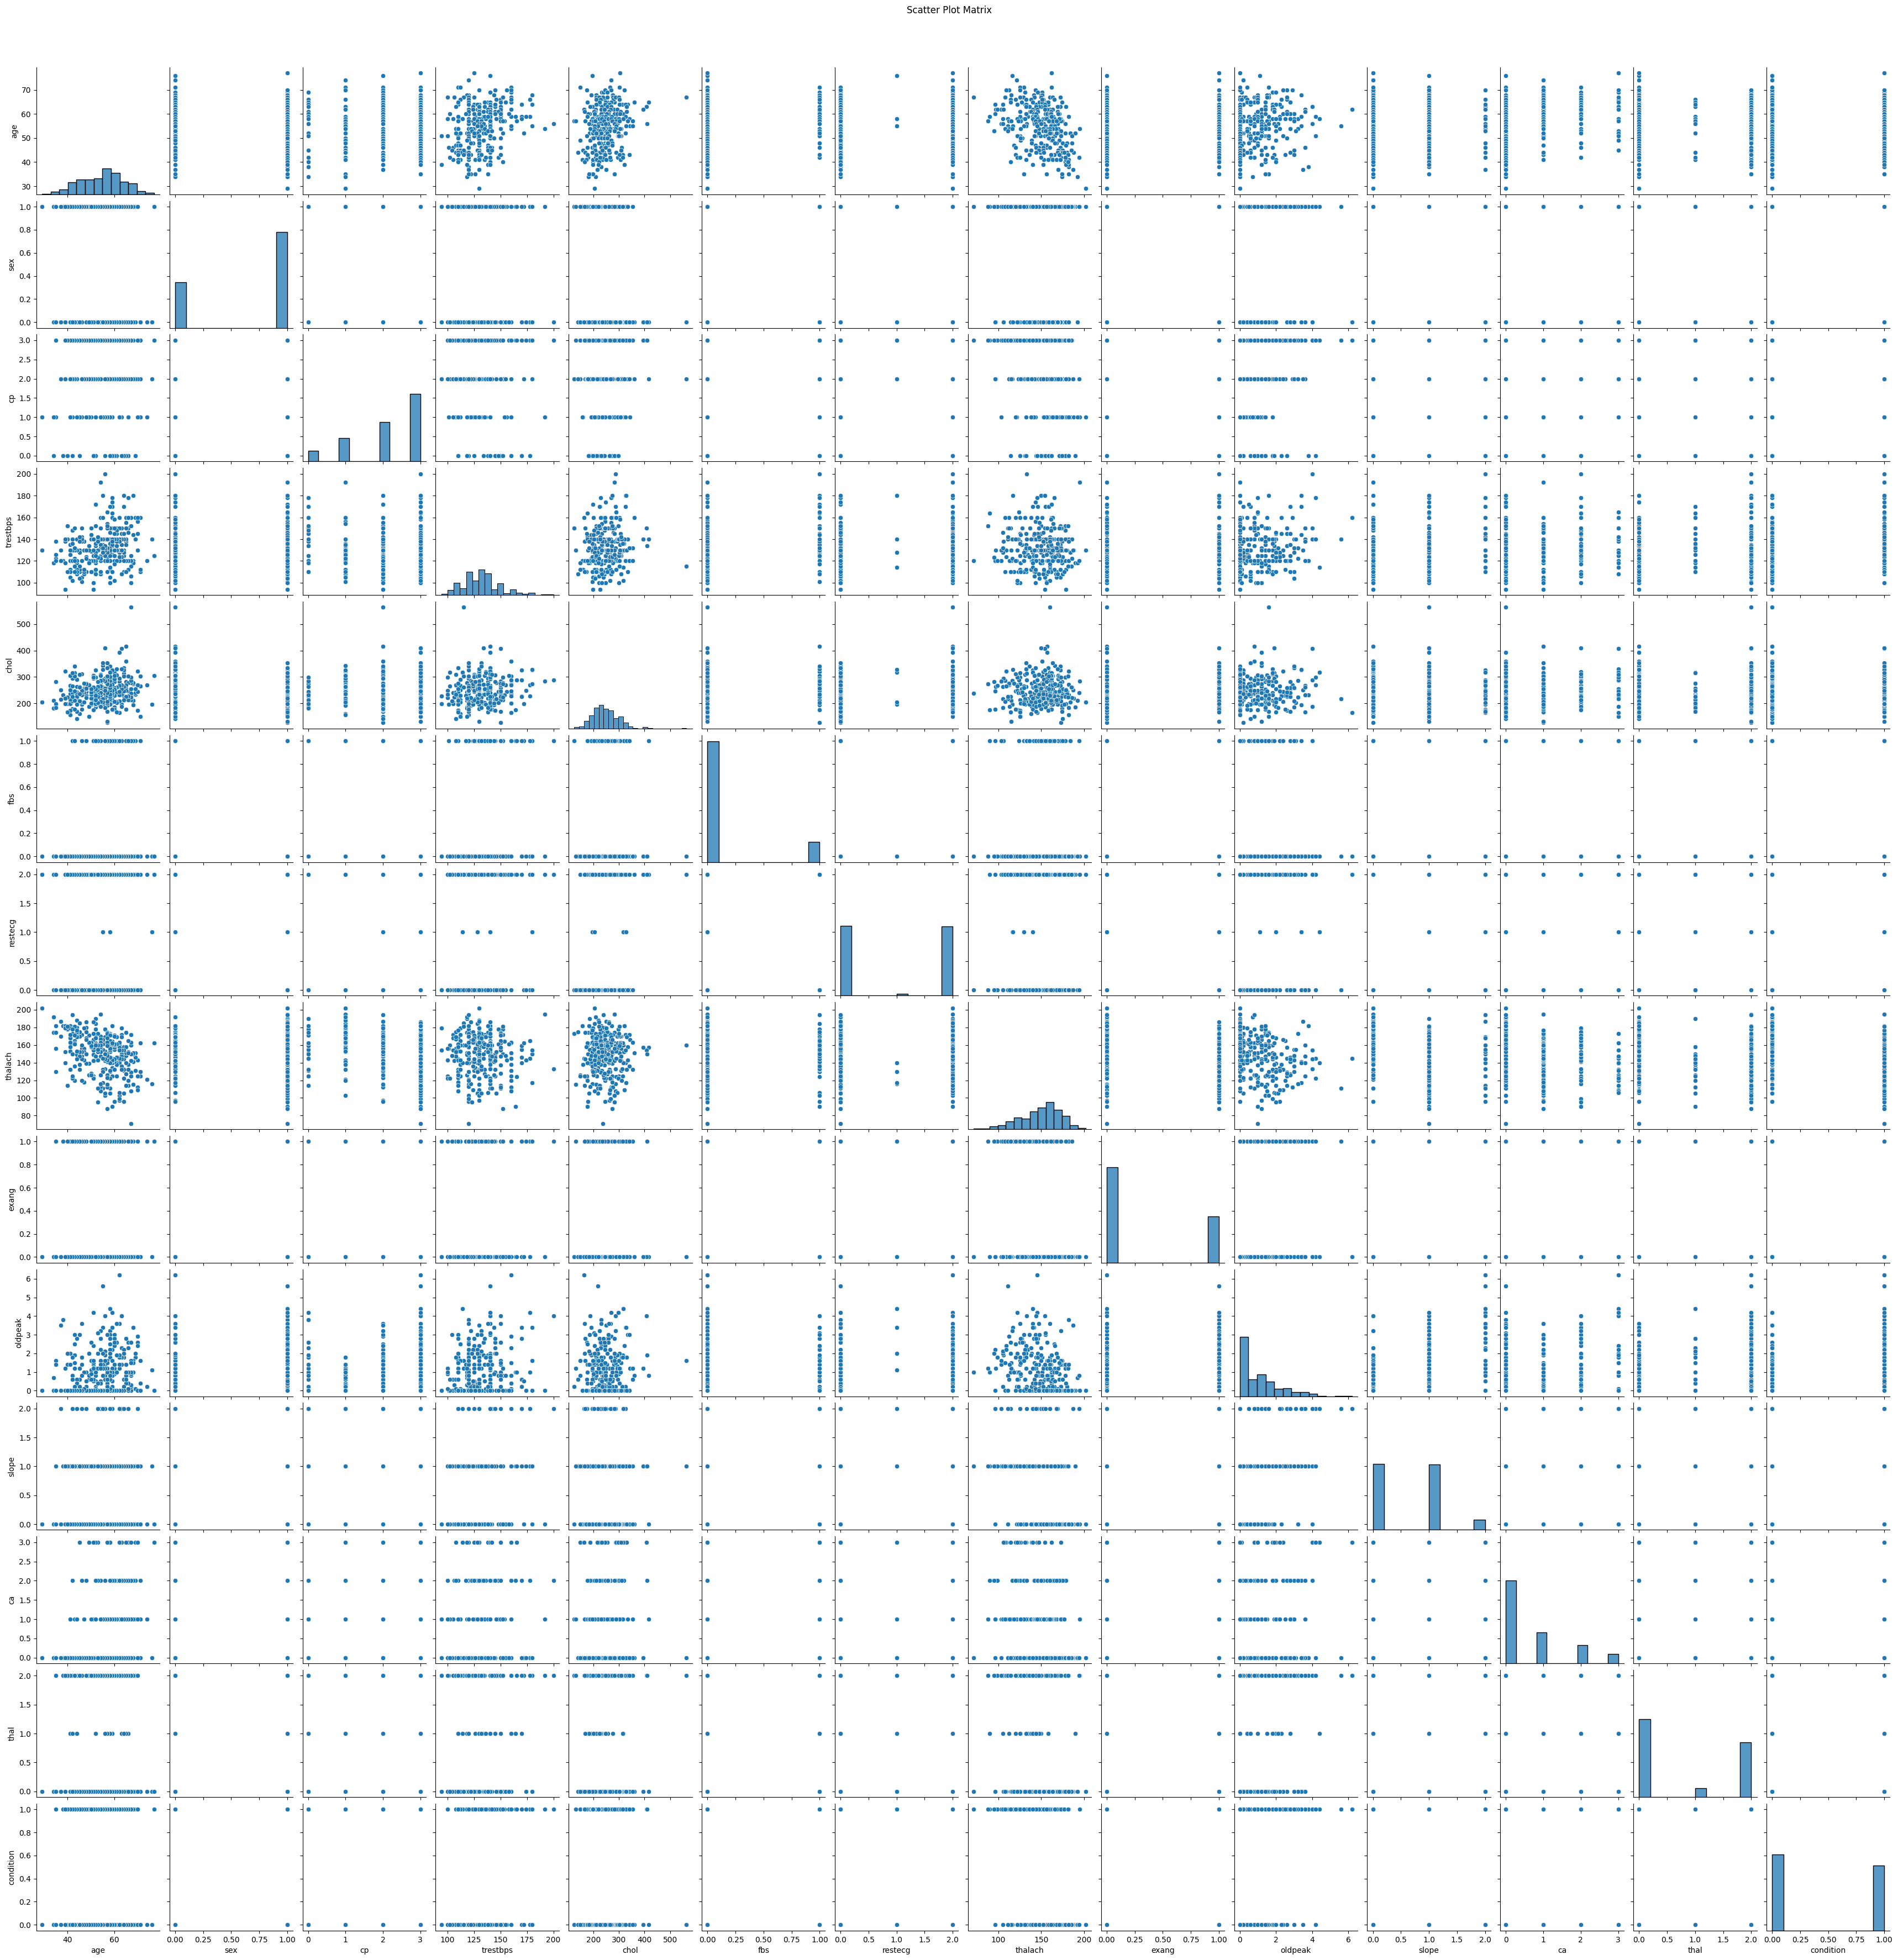

In [ ]:
# Step 4: Scatter plot matrix (pairplot)
sns.pairplot(numeric_df)
plt.suptitle('Scatter Plot Matrix', y=1.02)
plt.show()

### Additional Plots using Seaborn

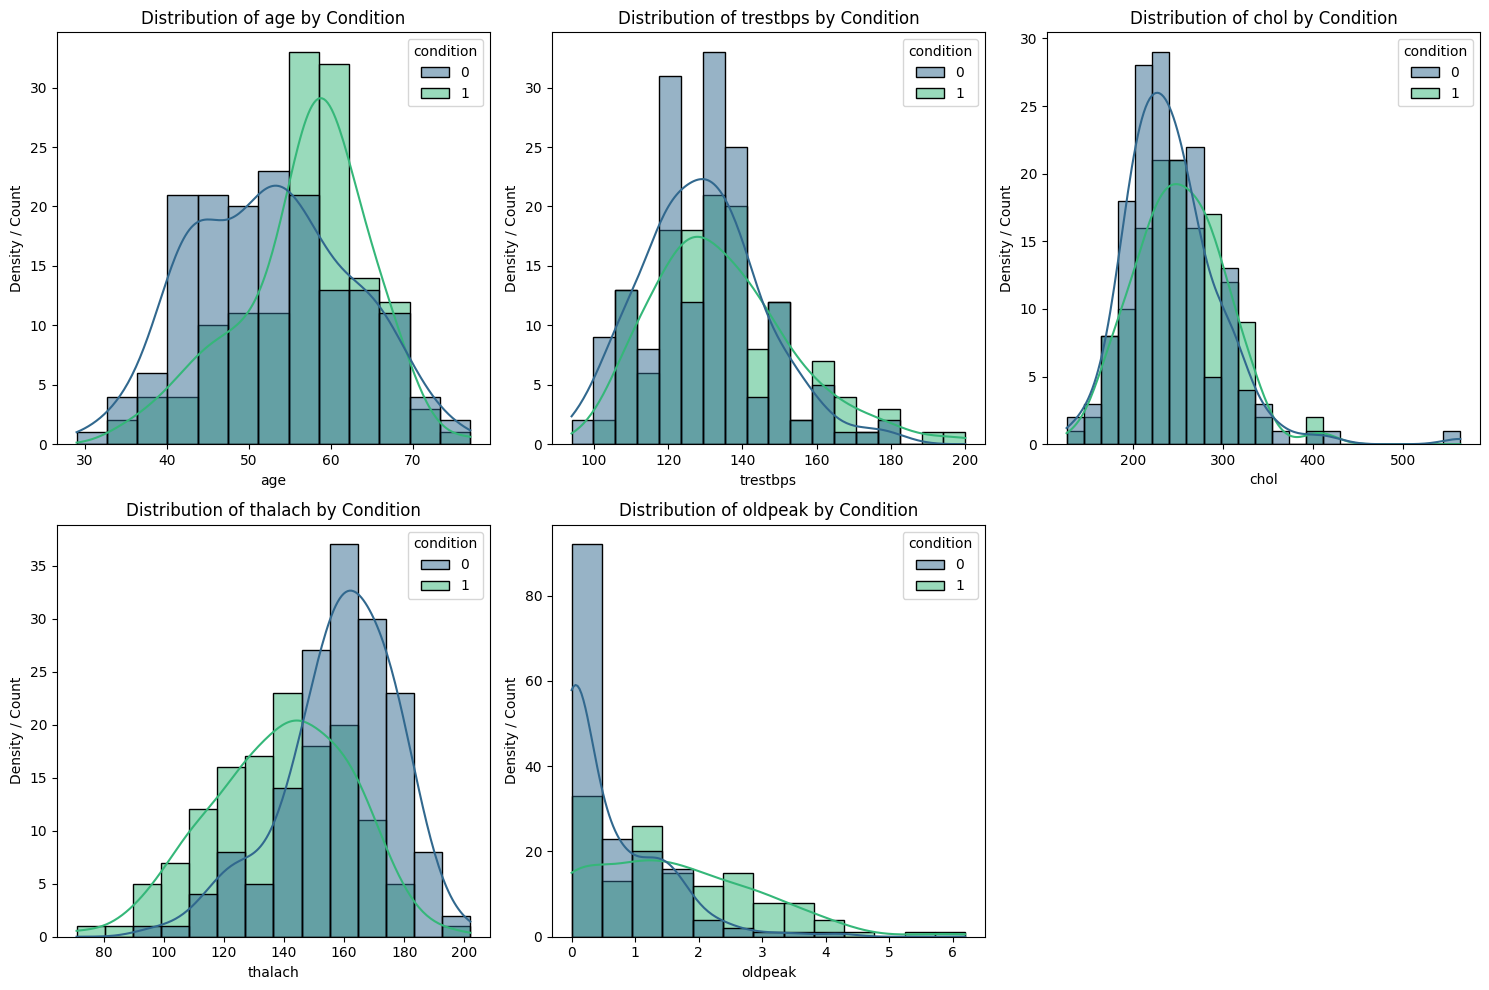

In [31]:
# Plot 1: Histograms/KDEs for key numerical features, separated by 'condition'

selected_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features):
    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns
    sns.histplot(data=df, x=feature, hue='condition', kde=True, palette='viridis')
    plt.title(f'Distribution of {feature} by Condition')
    plt.xlabel(feature)
    plt.ylabel('Density / Count')

plt.tight_layout()
plt.show()

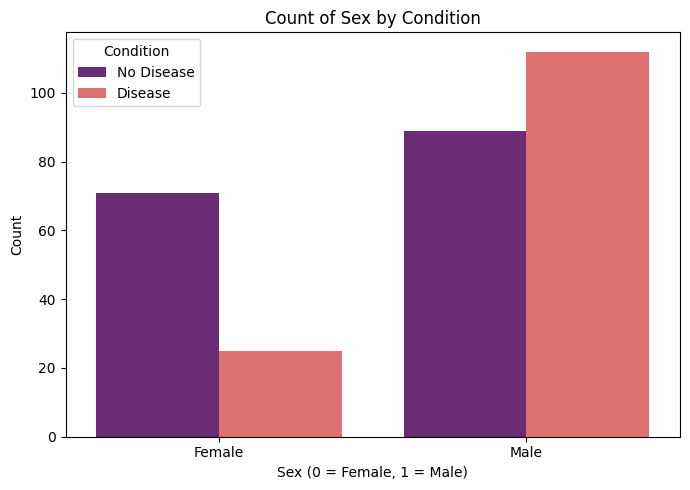

In [32]:
# Plot 2: Countplot for 'sex' by 'condition'

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='sex', hue='condition', palette='magma')
plt.title('Count of Sex by Condition')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Condition', labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.show()

/tmp/ipython-input-1511535077.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='condition', y='age', palette='coolwarm')


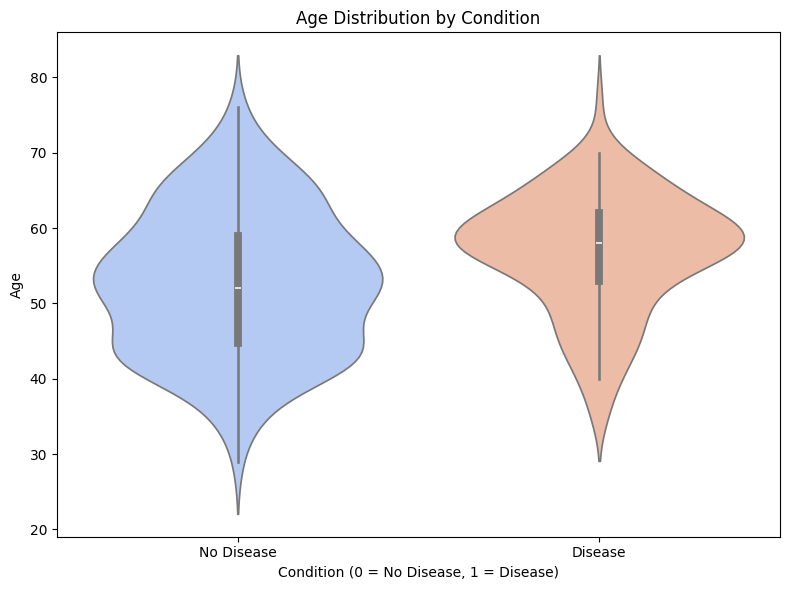

In [33]:
# Plot 3: Violin plot for 'age' by 'condition'

plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='condition', y='age', palette='coolwarm')
plt.title('Age Distribution by Condition')
plt.xlabel('Condition (0 = No Disease, 1 = Disease)')
plt.ylabel('Age')
plt.xticks(ticks=[0, 1], labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.show()

/tmp/ipython-input-4205537331.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cp', y='chol', palette='Set3')


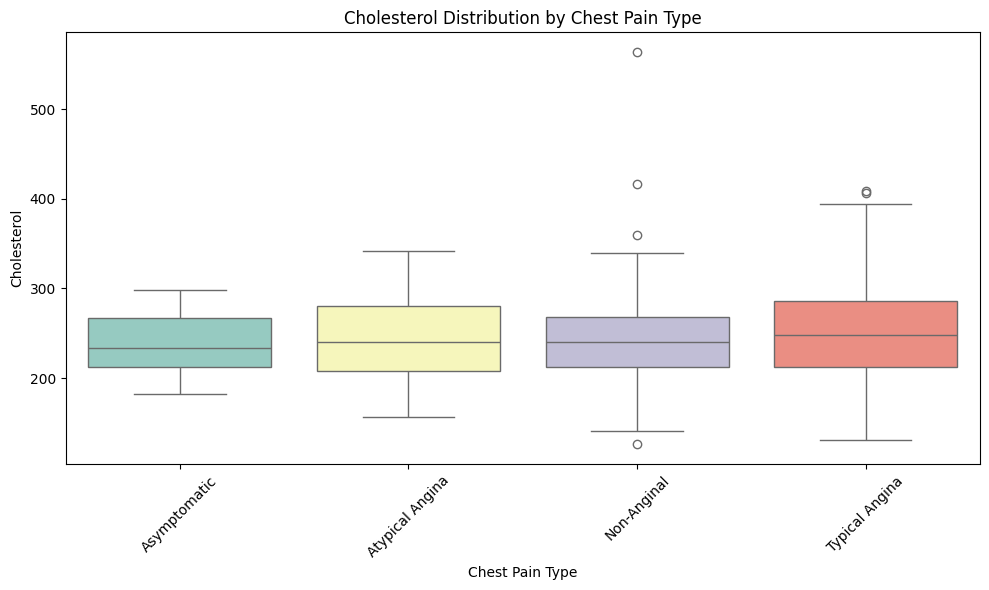

In [34]:
# Plot 4: Box plot for 'chol' by 'cp' (chest pain type)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='cp', y='chol', palette='Set3')
plt.title('Cholesterol Distribution by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Cholesterol')
# Assuming cp is categorical: 0: asymptomatic, 1: atypical angina, 2: non-anginal pain, 3: typical angina
plt.xticks(ticks=[0, 1, 2, 3], labels=['Asymptomatic', 'Atypical Angina', 'Non-Anginal', 'Typical Angina'], rotation=45)
plt.tight_layout()
plt.show()

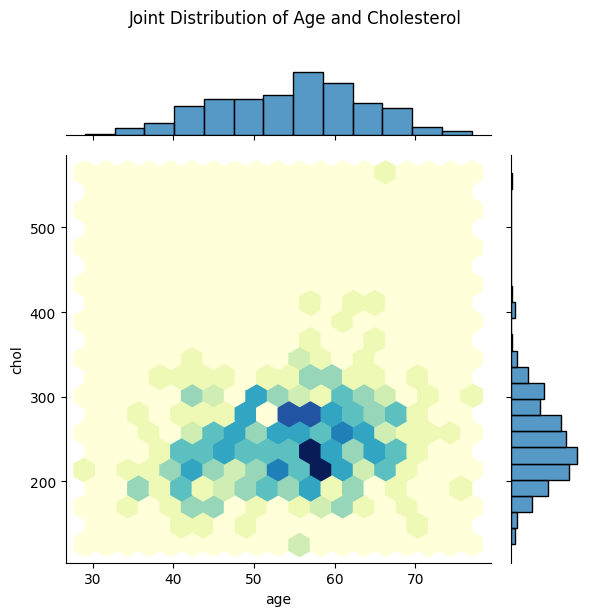

In [35]:
# Plot 5: Jointplot for 'age' and 'chol'

sns.jointplot(data=df, x='age', y='chol', kind='hex', cmap='YlGnBu')
plt.suptitle('Joint Distribution of Age and Cholesterol', y=1.02) # y is offset for suptitle
plt.tight_layout()
plt.show()